In [83]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # 보기좋은 그래프
import folium # 위도/경도데이터 지도에 표시
from folium.plugins import HeatMap

In [84]:
plt.style.use('ggplot')

In [85]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [86]:
df = pd.read_csv('jeju_bus.csv')
df

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,삼아아파트,33.251896,126.574417,96
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,매일올레시장 7번입구,33.249753,126.565959,50
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,아랑조을거리 입구,33.251084,126.559551,16
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,평생학습관,33.249504,126.558068,38


In [87]:
df.describe()
# distance, next_arrive_time의 평균과 최대값 차이가 매우큼 -> 분포/이상치 확인필요

,id,route_id,vh_id,now_latitude,now_longitude,distance,next_latitude,next_longitude,next_arrive_time
count,210457.000000,2.104570e+05,2.104570e+05,210457.000000,210457.000000,210457.000000,210457.000000,210457.000000,210457.000000
mean,105228.000000,4.052491e+08,7.988694e+06,33.434528,126.603451,490.256100,33.434711,126.603687,85.380824
std,60753.847139,9.132404e+04,6.774077e+03,0.102350,0.123961,520.563932,0.102224,0.123838,85.051170
min,0.000000,4.051360e+08,7.983000e+06,33.244382,126.473300,97.000000,33.244382,126.473300,6.000000
25%,52614.000000,4.051365e+08,7.983093e+06,33.325283,126.523900,291.000000,33.325283,126.524550,44.000000
50%,105228.000000,4.053201e+08,7.983431e+06,33.484667,126.551050,384.000000,33.484860,126.551050,66.000000
75%,157842.000000,4.053201e+08,7.997041e+06,33.500197,126.650322,542.000000,33.500228,126.650322,102.000000
max,210456.000000,4.053281e+08,7.997124e+06,33.556167,126.935188,7461.000000,33.556167,126.935188,2996.000000


In [ ]:
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_ratio': df.isnull().mean()
})
missing_df # 결측치 확인. 결측치는 없음

,missing_count,missing_ratio
id,0,0.0
date,0,0.0
route_id,0,0.0
vh_id,0,0.0
route_nm,0,0.0
now_latitude,0,0.0
now_longitude,0,0.0
now_station,0,0.0
now_arrive_time,0,0.0
distance,0,0.0


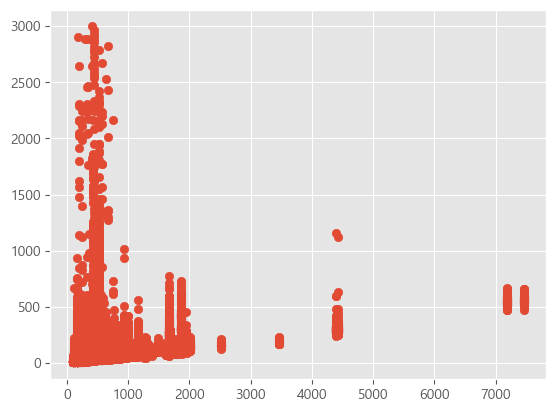

In [ ]:
from matplotlib import pyplot as plt
plt.scatter(df['distance'], df['next_arrive_time']) # 이상치가 있다고 판단된 두 컬럼 산점도 확인

In [ ]:
def prepare_features(df_input, required_cols, target_col):
    data = df_input.copy()
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f'필수 컬럼이 누락되었습니다: {missing_cols}')
    
    data['date'] = pd.to_datetime(data['date']) # 날짜형 변환
    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek
    
    data['now_hour'] = (
        data['now_arrive_time'].astype(str).str.extract(r"(\d+)").astype(float) #extract목적이 한그룹만 뽑아서 변환이기때문에 괄호로 묶음
    )

    data = data.drop(columns=['date', 'now_arrive_time'])
    #if target_col in data.columns:
    #    data = data.drop(columns=[target_col])
    # target_col써야돼서 유지
    if 'id' in data.columns:
        data = data.drop(columns=['id'])
    return data

In [91]:
df_model = df.copy()
data = prepare_features(df_model, df.columns[1:-1], df.columns[-1])
# target 분포확인
data['next_arrive_time'].describe()

count    210457.000000
mean         85.380824
std          85.051170
min           6.000000
25%          44.000000
50%          66.000000
75%         102.000000
max        2996.000000
Name: next_arrive_time, dtype: float64

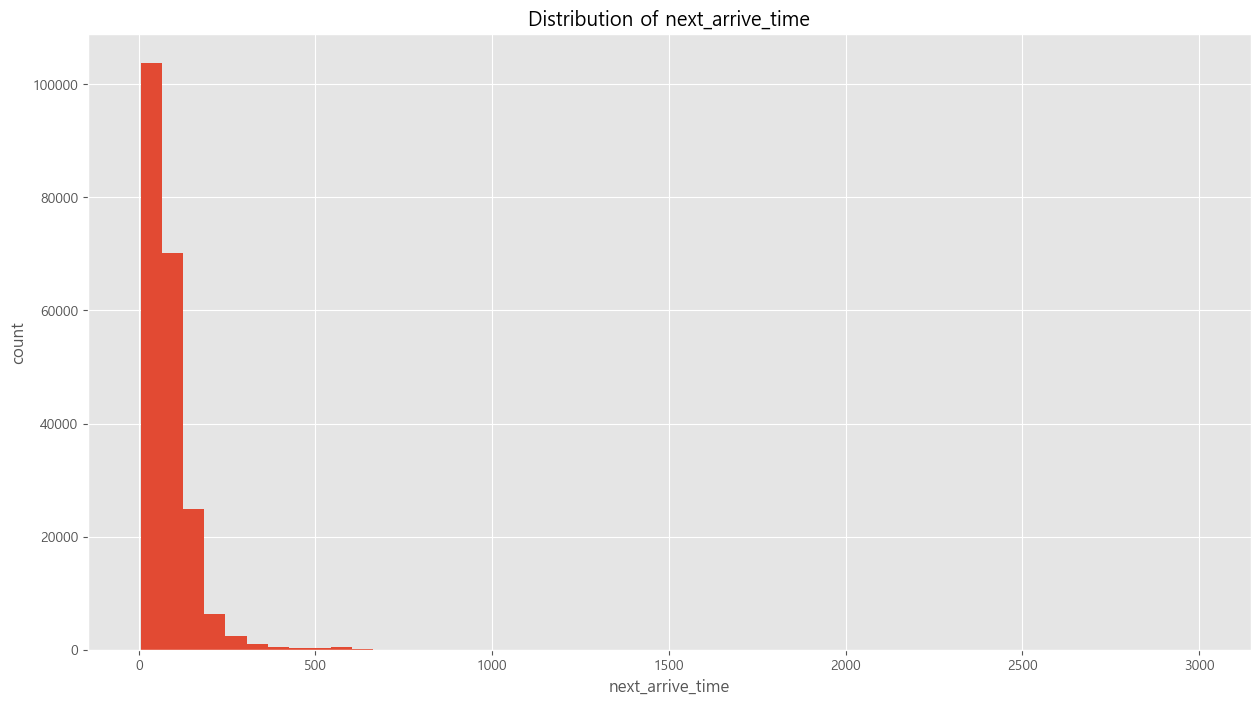

In [ ]:
fig, ax = plt.subplots(figsize=(15,8)) # 두 컬럼 히스토그램 확인. 값이 어디에 몰려있는지.
ax.hist(data['next_arrive_time'], bins=50)
ax.set_title('Distribution of next_arrive_time')
ax.set_xlabel('next_arrive_time')
ax.set_ylabel('count');
# 대부분 짧은 구간에 몰려있지만 오른쪽으로 긴 꼬리보임. 일부 매우 큰값(이상치) 존재

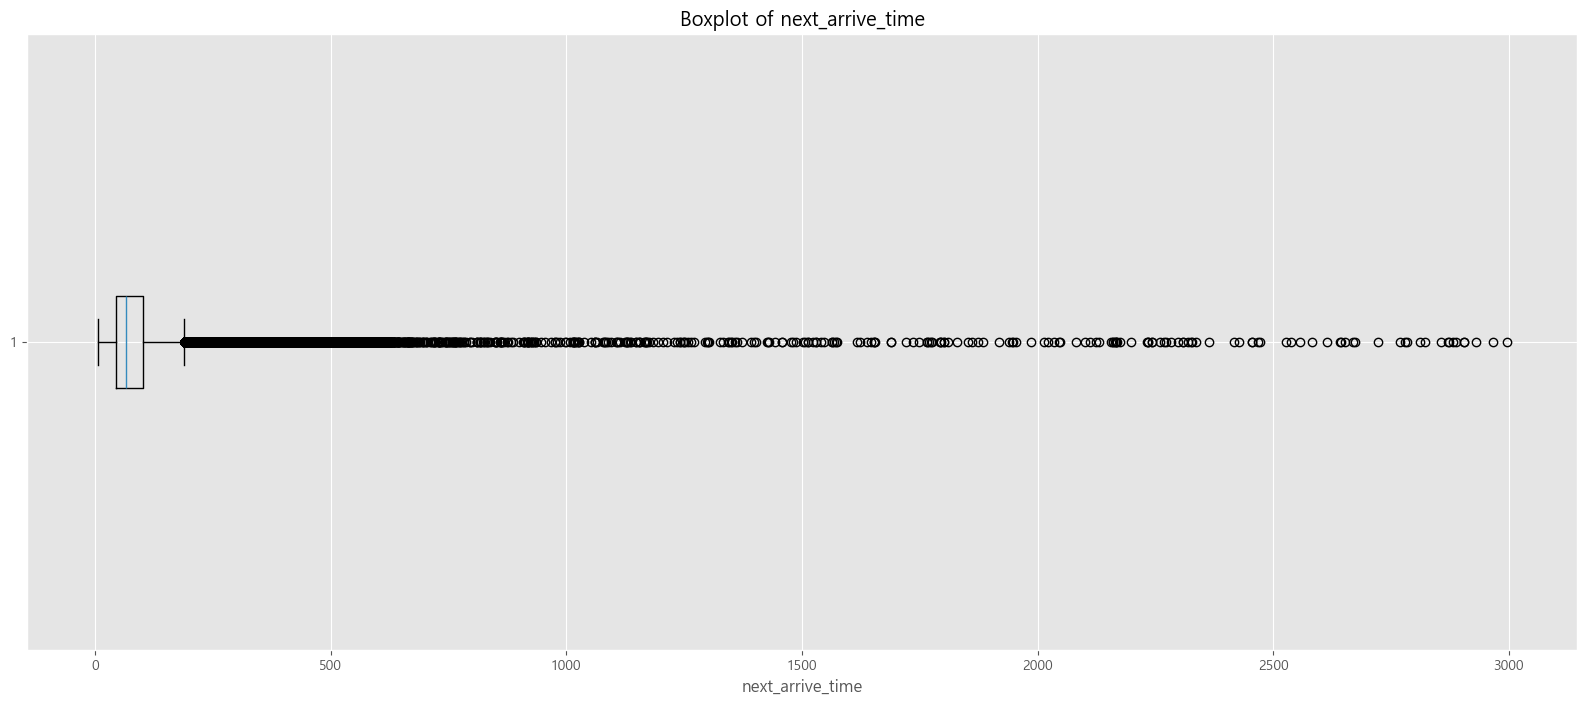

In [ ]:
fig, ax = plt.subplots(figsize=(20,8)) # 박스플롯으로 이상치 확인.
ax.boxplot(data['next_arrive_time'], vert=False)
ax.set_title('Boxplot of next_arrive_time')
ax.set_xlabel('next_arrive_time'); # Q3 + 1.5IQR이후에 값 분포 확인 가능(target 분포가 한쪽으로 치우쳐져 있기때문에 MAE, RMSE(큰오차에 민감)를 함께확인.)

In [ ]:
quantiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0] # 상위 몇% 정도가 어느정도 값인지 숫자로 확인
data['next_arrive_time'].quantile(quantiles) # 상위 1%와 최댓값의 차이가 큼. 극단적으로 큰값이 소수 존재

0.25      44.0
0.50      66.0
0.75     102.0
0.90     154.0
0.95     194.0
0.99     340.0
1.00    2996.0
Name: next_arrive_time, dtype: float64

In [95]:
over_300_count = (data['next_arrive_time'] > 300).sum()
over_600_count = (data['next_arrive_time'] > 600).sum()
over_1000_count = (data['next_arrive_time'] > 1000).sum()
over_300_count, over_600_count, over_1000_count

(np.int64(3070), np.int64(438), np.int64(200))

Text(0, 0.5, 'next_arrive_time')

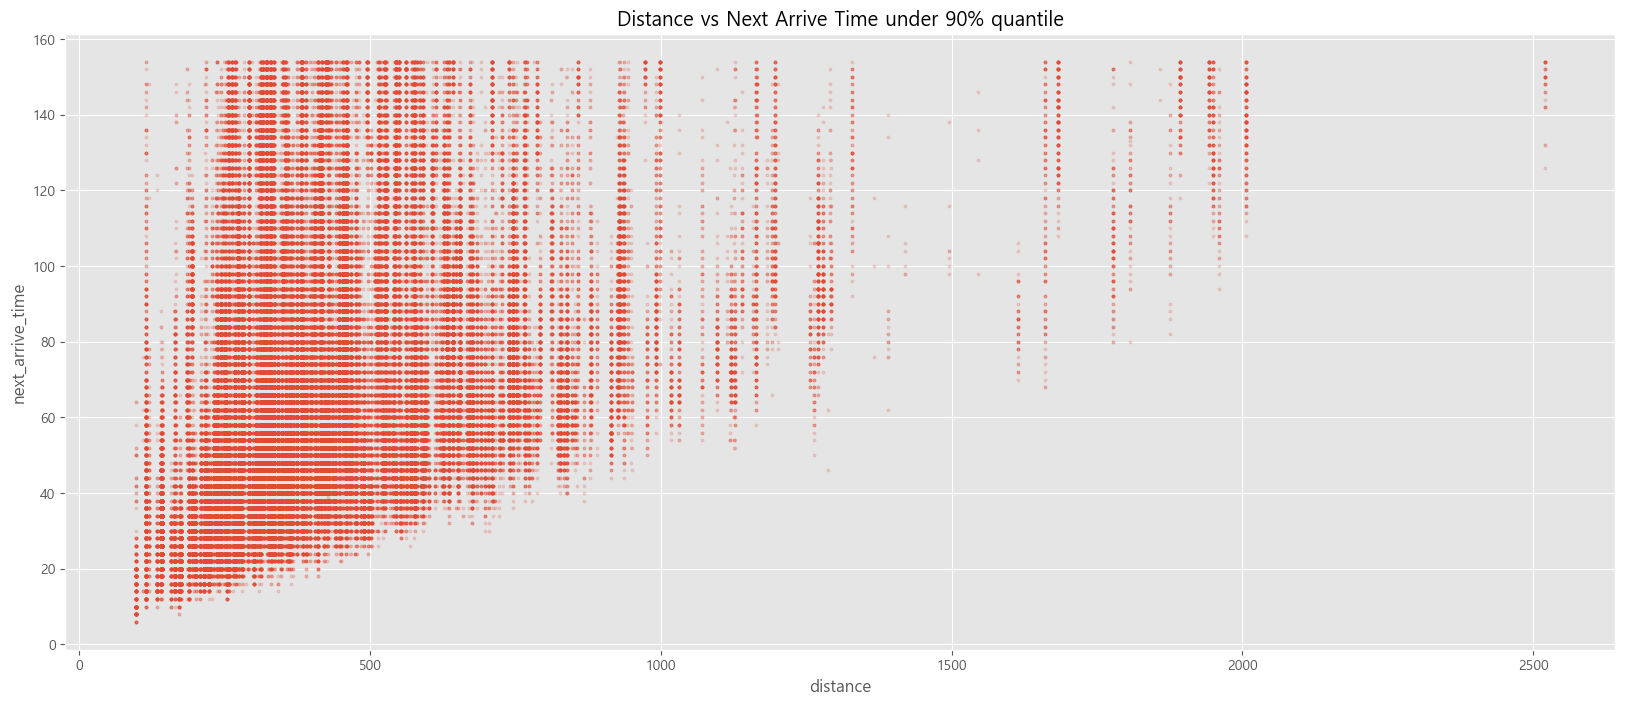

In [ ]:
q90 = data['next_arrive_time'].quantile(0.90) # 일반적인 구간의 관계를 또렷하게 보기위해 좀 널널하게 잡은 상위 10%
df_under_q90 = data[data['next_arrive_time'] <= q90]
fig, ax = plt.subplots(figsize=(20,8))
ax.scatter(
    df_under_q90['distance'],
    df_under_q90['next_arrive_time'],
    alpha=0.2,
    s=5
)
ax.set_title('Distance vs Next Arrive Time under 90% quantile')
ax.set_xlabel('distance')
ax.set_ylabel('next_arrive_time')
# 극단값을 제외해서 관계가 또렷히 보임. 최소 도착시간은 거리에 비례. 하지만 같은 거리에서도 도착시간이 넓게 퍼져있음.

In [97]:
corr_cols = [
    'distance',
    'next_arrive_time',
    'now_hour'
]

corr_data = data[corr_cols]
corr_matrix = corr_data.corr()
corr_matrix
# 0.5이상 : 상관관계 강함. 0.2 이상: 상관관계 있음. 0.2 미만: 상관관계 약함. 0: 상관관계 없음

,distance,next_arrive_time,now_hour
distance,1.000000,0.437166,-0.004834
next_arrive_time,0.437166,1.000000,-0.001209
now_hour,-0.004834,-0.001209,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

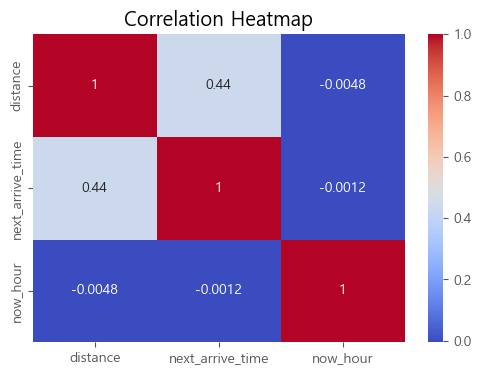

In [98]:
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
ax.set_title('Correlation Heatmap')

In [99]:
data[data['now_hour'] == 5].sort_values(by='next_arrive_time', ascending=False).head(30)

,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,distance,next_station,next_latitude,next_longitude,next_arrive_time,year,month,day,dayofweek,now_hour
66194,405136522,7997022,365-22,33.483527,126.475958,노형초등학교,347.0,정존마을,33.481317,126.473300,2468,2019,10,19,5,5.0
157456,405136522,7997056,365-22,33.483527,126.475958,노형초등학교,347.0,정존마을,33.481317,126.473300,2456,2019,10,25,4,5.0
127314,405136522,7997056,365-22,33.483527,126.475958,노형초등학교,347.0,정존마을,33.481317,126.473300,2176,2019,10,23,2,5.0
66462,405136522,7997056,365-22,33.483527,126.475958,노형초등학교,347.0,정존마을,33.481317,126.473300,2048,2019,10,19,5,5.0
78568,405136002,7997082,360-2,33.477560,126.477406,탐라도서관,518.0,제주고등학교/중흥S클래스,33.476260,126.481417,1946,2019,10,20,6,5.0
33053,405136002,7997082,360-2,33.477560,126.477406,탐라도서관,518.0,제주고등학교/중흥S클래스,33.476260,126.481417,1940,2019,10,17,3,5.0
107827,405136001,7997034,360-1,33.459893,126.561624,제주대학교,415.0,제대아파트,33.458783,126.557353,1802,2019,10,22,1,5.0
184493,405136012,7997041,360-12,33.458900,126.557300,제대아파트,435.0,제주대학교,33.460114,126.561659,1616,2019,10,27,6,5.0
1840,405136002,7997082,360-2,33.458900,126.557300,제대아파트,435.0,제주대학교,33.460114,126.561659,1372,2019,10,15,1,5.0
156049,405136521,7997001,365-21,33.458900,126.557300,제대아파트,435.0,제주대학교,33.460114,126.561659,1332,2019,10,25,4,5.0


In [ ]:
# 시간대별로 도착시간이 달라지는지 확인. 시간기반 feature가 필요한지 판단.
# 우선 데이터 적은 시간대의 평균은 신뢰도가 낮으므로 제외하기위해 개수 확인
hour_count = data.groupby('now_hour')['next_arrive_time'].count() 
hour_count

now_hour
0.0         5
5.0       487
6.0      8409
7.0     13581
8.0     13838
9.0     13700
10.0    13011
11.0    12524
12.0    13433
13.0    13197
14.0    12592
15.0    12846
16.0    13476
17.0    13090
18.0    12987
19.0    13275
20.0    11852
21.0    11230
22.0     6470
23.0      454
Name: next_arrive_time, dtype: int64

In [ ]:
# 평균 도착시간확인
hour_mean_time = data.groupby('now_hour')['next_arrive_time'].mean()
hour_mean_time

now_hour
0.0      56.000000
5.0     132.956879
6.0      85.986443
7.0      85.488697
8.0      87.666715
9.0      82.414015
10.0     82.623780
11.0     83.547988
12.0     83.550733
13.0     84.070471
14.0     84.036134
15.0     84.904250
16.0     86.759573
17.0     90.705271
18.0     94.958882
19.0     87.240979
20.0     83.124705
21.0     82.479252
22.0     75.355796
23.0     63.387665
Name: next_arrive_time, dtype: float64

In [ ]:
# 개수, 평균, 중앙값 한번에 확인
hour_summary = data.groupby('now_hour')['next_arrive_time'].agg(
    ['count', 'mean', 'median']
)
hour_summary

,count,mean,median
now_hour,,,
0.0,5,56.000000,36.0
5.0,487,132.956879,66.0
6.0,8409,85.986443,64.0
7.0,13581,85.488697,66.0
8.0,13838,87.666715,66.0
9.0,13700,82.414015,64.0
10.0,13011,82.623780,66.0
11.0,12524,83.547988,66.0
12.0,13433,83.550733,66.0


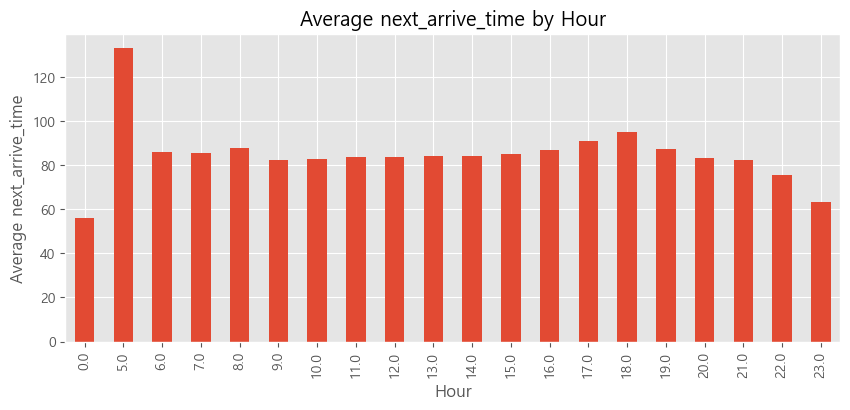

In [ ]:
hour_summary['mean'].plot(kind='bar', figsize=(10,4))
plt.title('Average next_arrive_time by Hour')
plt.xlabel('Hour')
plt.ylabel('Average next_arrive_time');
# 특정시간대(5시)에 평균도착시간이 튀는 것을 확인. 시간관련 feature(now_hour)가 모델에 필요하다는 근거.

In [ ]:
# 같은 방식으로 요일도 필요한지 판단
day_count = data.groupby('dayofweek')['next_arrive_time'].count()
day_count

dayofweek
0    30353
1    31311
2    30818
3    30968
4    30003
5    28806
6    28198
Name: next_arrive_time, dtype: int64

In [105]:
day_mean_time = data.groupby('dayofweek')['next_arrive_time'].mean()
day_mean_time

dayofweek
0    85.926136
1    85.476095
2    86.133721
3    86.487632
4    86.913709
5    83.720544
6    82.714732
Name: next_arrive_time, dtype: float64

In [106]:
day_summary = data.groupby('dayofweek')['next_arrive_time'].agg(
    ['count', 'mean', 'median']
)
day_summary

,count,mean,median
dayofweek,,,
0,30353,85.926136,66.0
1,31311,85.476095,66.0
2,30818,86.133721,66.0
3,30968,86.487632,66.0
4,30003,86.913709,66.0
5,28806,83.720544,64.0
6,28198,82.714732,64.0


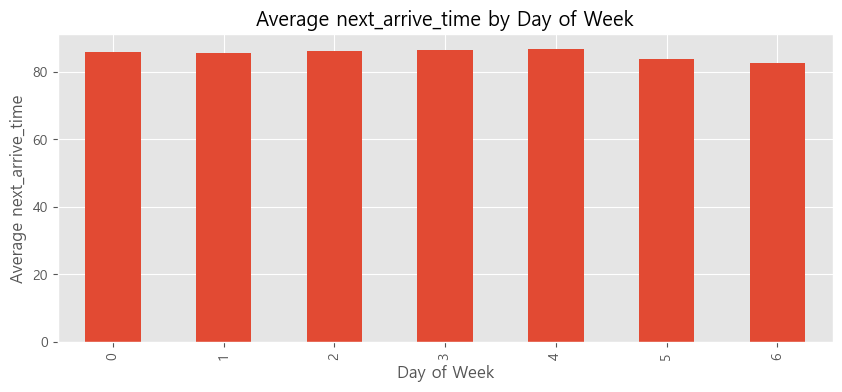

In [ ]:
day_summary['mean'].plot(kind='bar', figsize=(10,4))
plt.title('Average next_arrive_time by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average next_arrive_time');
# 요일은 별차이안남. 필요없음.

In [ ]:
# 노선별로도 확인
route_count = data.groupby('route_nm')['next_arrive_time'].count()
route_count

route_nm
201-11     7895
201-12    11871
201-13     2631
201-14    12999
201-15     2289
201-16    15451
201-17     5102
201-18     2558
201-21     2670
201-22     7723
201-24     2368
201-26     2665
201-27     5950
281-1     19150
281-2     25884
360-1     21668
360-12     8037
360-2      7709
360-7      2070
365-21    11826
365-22    31941
Name: next_arrive_time, dtype: int64

In [109]:
route_summary = data.groupby('route_nm')['next_arrive_time'].agg(
    ['count', 'mean', 'median']
)
route_summary = route_summary.sort_values('mean', ascending=False)
route_summary

,count,mean,median
route_nm,,,
365-21,11826,114.673939,90.0
360-12,8037,111.322633,82.0
360-2,7709,108.270852,84.0
365-22,31941,101.339188,80.0
360-7,2070,94.172947,82.0
360-1,21668,92.063688,80.0
281-1,19150,87.579634,68.0
281-2,25884,85.744862,70.0
201-15,2289,71.313237,54.0


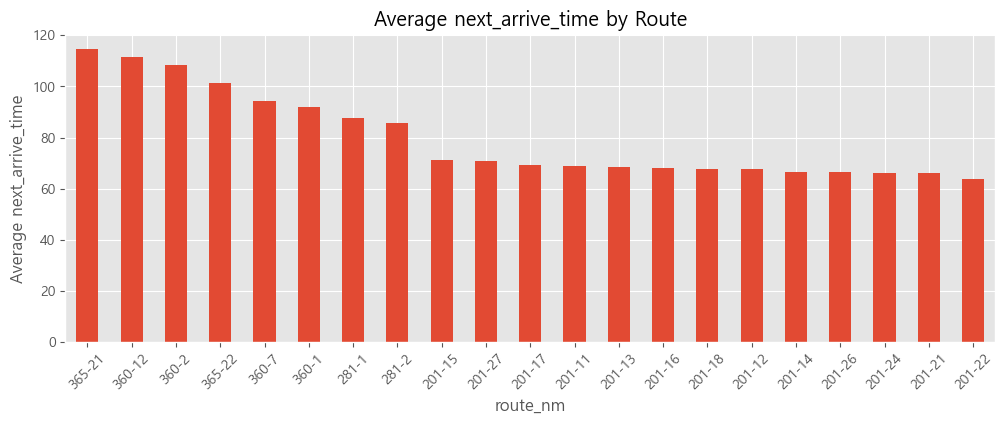

In [ ]:
route_summary['mean'].plot(kind='bar', figsize=(12,4))
plt.title('Average next_arrive_time by Route')
plt.xlabel('route_nm')
plt.ylabel('Average next_arrive_time');
plt.xticks(rotation=45);
# 노선마다 평균 시간이 다름. 의미있는 feature가 될 수 있음

In [ ]:
# 세부 정류장 -> 정류장 컬럼을 새로 생성. 구간별로 시간 확인
data['station_segment'] = (
    data['now_station'] + '->' + data['next_station']
)
data['station_segment'].head()

0                 제주대학교입구->제대마을
1                   제대마을->제대아파트
2                  제대아파트->제주대학교
3    남국원(아라방면)->제주여자중고등학교(아라방면)
4                      도호동->은남동
Name: station_segment, dtype: str

In [57]:
segment_count = data.groupby('station_segment')['next_arrive_time'].count()
segment_count.sort_values(ascending=False).head(10)

station_segment
은남동->도호동                             1933
남국원(아라방면)->아라초등학교                    1915
아라초등학교->아라주공아파트                      1911
제원아파트->은남동                           1897
아라주공아파트->인다마을                        1849
제주여자중고등학교(아라방면)->남국원(아라방면)           1794
인다마을->제주대학교병원                        1779
제주중앙여자고등학교(아라방면)->제주여자중고등학교(아라방면)    1761
제주시청(아라방면)->고산동산(아라방면)               1760
제주지방법원(아라방면)->제주중앙여자고등학교(아라방면)       1741
Name: next_arrive_time, dtype: int64

In [113]:
segment_summary = data.groupby('station_segment')['next_arrive_time'].agg(
    ['count', 'mean', 'median']
)
segment_summary = segment_summary[segment_summary['count'] >= 100]
segment_summary = segment_summary.sort_values('mean', ascending=False)
segment_summary.head(10)

,count,mean,median
station_segment,,,
탐라도서관->제주고등학교/중흥S클래스,380,613.400000,547.0
성판악->수악교,269,562.773234,560.0
수악교->성판악,319,551.072100,548.0
시티주유소->제주한라대학교(종점),227,423.162996,68.0
제주도청 신제주로터리->제주국제공항(구제주방면),815,360.272393,338.0
고성리제주은행->성산환승정류장(고성리 회전교차로),332,327.722892,337.0
성판악->교래입구,421,314.931116,308.0
고성리 구 성산농협->성산환승정류장(고성리 한국물류),170,302.235294,336.0
교래입구->성판악,387,301.922481,296.0


In [114]:
up = (33.506286, 126.490312)
right = (33.493521, 126.895326)
center = (33.379724, 126.545315)
down = (33.246742, 126.562387)

In [115]:
jeju_map = folium.Map(
    location=[33.38, 126.55], zoom_start=10, tiles='CartoDB positron'
)
folium.Marker(
    location=[up[0], up[1]],
    popup = '제주공항',
    tooltip='제주공항',
    icon=folium.Icon(color='blue')
).add_to(jeju_map)

In [116]:
folium.Marker(
    location=[right[0], right[1]],
    popup = '성산일출봉 방면',
    tooltip='성산일출봉 방면',
    icon=folium.Icon(color='green')
).add_to(jeju_map)

In [117]:
folium.Marker(
    location=[center[0], center[1]],
    popup = '한라산',
    tooltip='한라산',
    icon=folium.Icon(color='red')
).add_to(jeju_map)

In [118]:
folium.Marker(
    location=[down[0], down[1]],
    popup = '서귀포 방면',
    tooltip='서귀포 방면',
    icon=folium.Icon(color='red')
).add_to(jeju_map)

In [119]:
station_location_df = df[['now_station', 'now_latitude', 'now_longitude']].drop_duplicates()

In [120]:
for _, row in station_location_df.iterrows(): # enumerate처럼 인덱스 반환
    folium.CircleMarker(
        location=[row['now_latitude'], row['now_longitude']],
        radius=2,
        fill=True,
        fill_opacity=0.5,
        popup=row['now_station']
    ).add_to(jeju_map)

In [121]:
jeju_map

In [122]:
jeju_heatmap = folium.Map(
    location=[33.38, 126.55], zoom_start=10
)

heat_data = station_location_df[['now_latitude', 'now_longitude']].values.tolist()

HeatMap(
    heat_data,
    radius=15,
    blur=20
).add_to(jeju_heatmap)


In [123]:
folium.Marker(
    location=[up[0], up[1]],
    popup = '제주공항',
    tooltip='제주공항',
    icon=folium.Icon(color='blue')
).add_to(jeju_heatmap)

folium.Marker(
    location=[right[0], right[1]],
    popup = '성산일출봉 방면',
    tooltip='성산일출봉 방면',
    icon=folium.Icon(color='green')
).add_to(jeju_heatmap)

folium.Marker(
    location=[center[0], center[1]],
    popup = '한라산',
    tooltip='한라산',
    icon=folium.Icon(color='red')
).add_to(jeju_heatmap)

folium.Marker(
    location=[down[0], down[1]],
    popup = '서귀포 방면',
    tooltip='서귀포 방면',
    icon=folium.Icon(color='purple')
).add_to(jeju_heatmap)

In [124]:
jeju_heatmap

In [125]:
time_q99 = df['next_arrive_time'].quantile(0.99) # 도착시간 상위 1퍼 데이터로 distance, nextarrivetime 비교
time_q99

np.float64(340.0)

In [126]:
long_time_df = df[df['next_arrive_time'] >= time_q99]
long_time_df[[
    'route_nm', 'now_station', 'next_station', 'distance', 'now_arrive_time', 'next_arrive_time'
]].sort_values('next_arrive_time', ascending=False).head(50)

,route_nm,now_station,next_station,distance,now_arrive_time,next_arrive_time
35950,365-22,제주대학교,제대아파트,415.0,18시,2996
34404,360-12,제주대학교,제대아파트,435.0,19시,2966
110733,365-21,제대아파트,제주대학교,435.0,07시,2930
2003,360-2,제대아파트,제주대학교,435.0,17시,2906
150855,281-1,한국병원,제주버스터미널(가상정류소),188.0,08시,2906
125929,365-21,한라병원,삼무공원사거리,335.0,06시,2888
158593,365-22,삼무공원사거리,한라병원,291.0,21시,2882
201187,365-22,제대아파트,제주대학교,415.0,18시,2874
95465,365-21,제대아파트,제주대학교,435.0,16시,2870
19864,365-21,제대아파트,제주대학교,435.0,18시,2856


In [128]:
top_50 = long_time_df.sort_values(by='next_arrive_time', ascending=False).head(50)
jeju_map = folium.Map(location=[33.38, 126.55])
for _, row in top_50.iterrows(): # enumerate처럼 인덱스 반환
    folium.Marker(
        location=[row['now_latitude'], row['now_longitude']],
        radius=2,
        popup=row['now_station']
    ).add_to(jeju_map)
jeju_map

### 결론
1. target(next_arrive_time) 이상치 확인 필요.  MAE, RMSE를 함께 확인해야됨
2. distance와 target 비례관계 존재. 다른 feature도 확인필요
3. now_arrive_time -> now_hour 등 시간컬럼 전처리 필요
4. route_nm 등 범주형 컬럼 전처리, onehotencoding필요
5. 위치분포 확인
6. 거리, 시간 모두 길면 자연스러운 장거리 구간일 수 있음. 거리가 짧은데 시간이 길면 이상치

#### baseline에서 사용할 컬럼
- distance
- now_hour
- day
- dayofweek
- route_nm
- now_station
- next_station

#### 사용안할 컬럼
- year, month
- speed
- station_segment
- id, route_id